In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

Original Image Shape: (300, 300, 1)


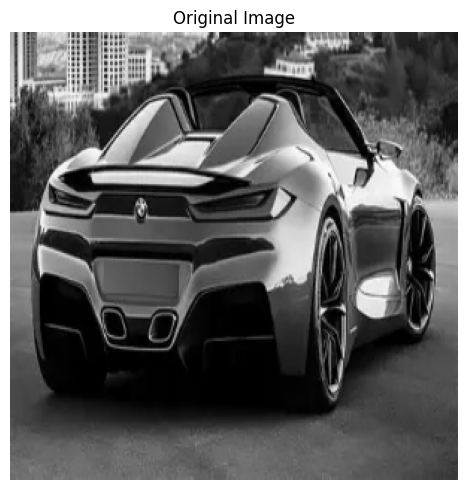

In [ ]:
image_path = r"C:\AI_Learning\Week5\Day4\car.png"

image = tf.io.read_file(image_path) #Reads image file as raw binary data.
image = tf.io.decode_jpeg(image, channels=1)   #convert jpeg to pixel values and specify 1 channel for grayscale
image = tf.image.resize(image, [300, 300]) #Resize the image to 300x300 pixels.
image = tf.image.convert_image_dtype(image, tf.float32)#Convert the pixel values to the range [0, 1] by dividing by 255.0.

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

In [ ]:
#Defining kernel/filter
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])#defining shapes

After Convolution Shape: (1, 300, 300, 1)


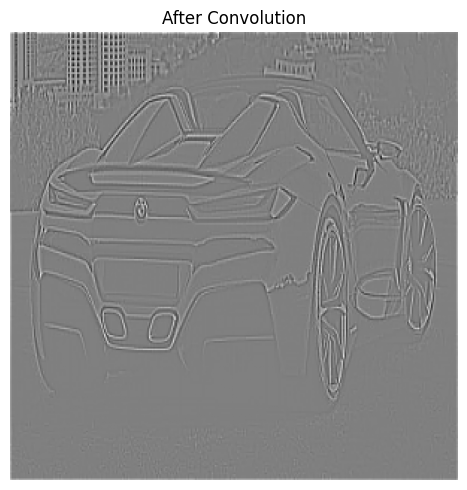

In [ ]:
#Perform convolution
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

After ReLU Shape: (1, 300, 300, 1)


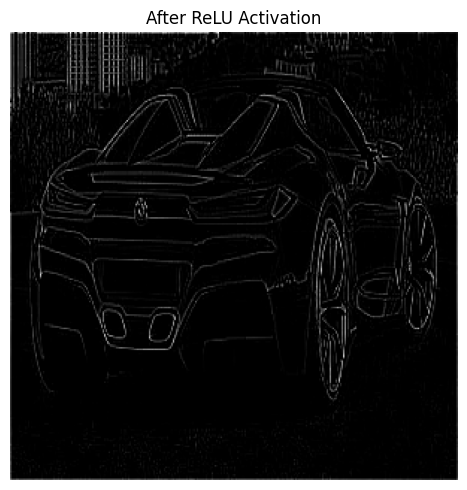

In [ ]:
#applying relu
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

After Pooling Shape: (1, 150, 150, 1)


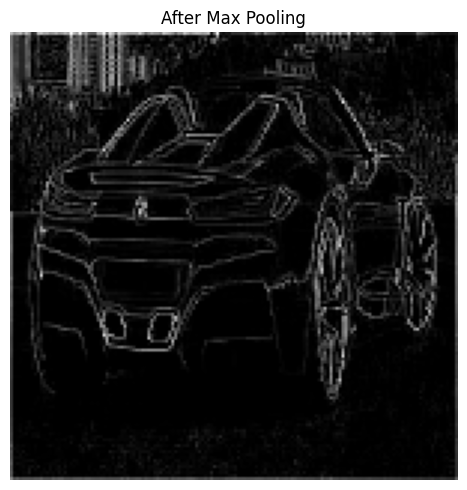

In [ ]:
#max pooling
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

In [ ]:
#flattening
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[815.21674 649.351   723.1819  783.56    567.55005 795.07434 639.3188
 179.20479 254.26678 792.412   812.7345  682.0652  727.39044 606.92664
 647.4686  731.93823 609.7382  655.9794  753.547   667.97894]


In [ ]:
dense_layer = tf.keras.layers.Dense(
    units=64,         
    activation='relu' 
) #dense layer  is connected to every input neuron and has 64 output neurons with relu activation function

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)
